In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Importing the data set
data = pd.read_csv("professor_rating_dataset.csv")

In [3]:
print(data.head())
print(data.tail())

   professor_id  gender tenure  beauty  students  rating
0             1    Male    Yes   -0.53      72.0    3.60
1             2  Female     No   -0.79      70.0    3.86
2             3  Female    Yes   -0.11      58.0    3.96
3             4  Female     No   -1.04      80.0    4.34
4             5    Male    Yes   -0.55      10.0    4.10
     professor_id  gender tenure  beauty  students  rating
195           196    Male     No    0.70      44.0    3.63
196           197  Female     No    1.85      12.0    4.46
197           198  Female    Yes    1.13      53.0    3.64
198           199  Female    Yes   -0.27      60.0    3.75
199           200  Female    Yes   -1.11      21.0    2.96


In [4]:
data.isnull().sum()

professor_id    0
gender          0
tenure          0
beauty          3
students        3
rating          3
dtype: int64

In [5]:
data.fillna(inplace=True, value=0)

,professor_id,gender,tenure,beauty,students,rating
0,1,Male,Yes,-0.53,72.0,3.60
1,2,Female,No,-0.79,70.0,3.86
2,3,Female,Yes,-0.11,58.0,3.96
3,4,Female,No,-1.04,80.0,4.34
4,5,Male,Yes,-0.55,10.0,4.10
...,...,...,...,...,...,...
195,196,Male,No,0.70,44.0,3.63
196,197,Female,No,1.85,12.0,4.46
197,198,Female,Yes,1.13,53.0,3.64
198,199,Female,Yes,-0.27,60.0,3.75


In [6]:
# rechack null values
data.isnull().sum()

professor_id    0
gender          0
tenure          0
beauty          0
students        0
rating          0
dtype: int64

## Q1. Time Series or Cross-Sectional?

**Answer:** This data is **Cross-sectional**.

Each row represents a *different* professor/course observed at a single point in time — the same professor is not tracked repeatedly across multiple time periods, and there is no date/time variable in the dataset.

## Q2. Mean, Median, Minimum, Maximum for Students

In [7]:
print("Mean :", data['students'].mean())
print("Median :", data['students'].median())
print("Minimum :", data['students'].min())
print("Maximum :", data['students'].max())

Mean : 52.515
Median : 49.5
Minimum : 0.0
Maximum : 100.0


## Q3. Descriptive Statistics Table

In [8]:
data[['students', 'beauty', 'rating']].describe()

,students,beauty,rating
count,200.000000,200.000000,200.000000
mean,52.515000,-0.067200,4.015100
std,26.755918,1.004653,0.696883
min,0.000000,-2.500000,0.000000
25%,30.750000,-0.775000,3.710000
50%,49.500000,-0.110000,4.085000
75%,75.000000,0.572500,4.372500
max,100.000000,2.500000,5.000000


## Q4. Histogram of the Beauty Variable

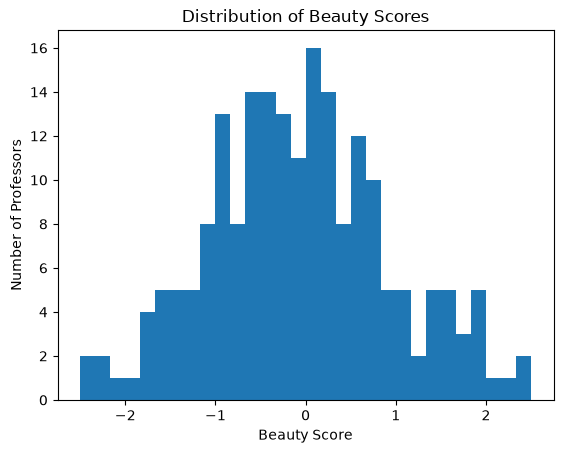

In [9]:
plt.hist(data['beauty'], bins=30)
plt.xlabel('Beauty Score')
plt.ylabel('Number of Professors')
plt.title('Distribution of Beauty Scores')
plt.show()

## Q5. Does Average Beauty Score Differ by Gender?

In [10]:
beauty_by_gender = data.groupby('gender')['beauty'].agg(['mean', 'std', 'count'])
print(beauty_by_gender)

            mean       std  count
gender                           
Female -0.102439  0.955317     82
Male   -0.042712  1.040875    118


## Q6. Tenure Status by Gender

In [11]:
tenure_pct = data.groupby('gender')['tenure'].apply(lambda x: (x == 'yes').mean() * 100)
print("Percentage tenured by gender:\n", tenure_pct)

print("\nCross-tab of counts:")
print(pd.crosstab(data['gender'], data['tenure']))

Percentage tenured by gender:
 gender
Female    0.0
Male      0.0
Name: tenure, dtype: float64

Cross-tab of counts:
tenure  No  Yes
gender         
Female  35   47
Male    39   79
